Download necessary libraries to process the dataset

In [21]:
#!pip install pandas numpy matplotlib scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path #To manage the routes of the data
import gzip #As the data comes in .gz packages
import struct

Load the Dataset

In [ ]:
DATA_DIR = Path("./data")

train_images_path = DATA_DIR / "train-images-idx3-ubyte.gz"
train_labels_path = DATA_DIR / "train-labels-idx1-ubyte.gz"

test_images_path = DATA_DIR / "t10k-images-idx3-ubyte.gz"
test_labels_path = DATA_DIR / "t10k-labels-idx1-ubyte.gz"

Loading the training images dataset

In [ ]:
with gzip.open(train_images_path, "rb") as f:
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_images = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset
    num_rows = struct.unpack(">I", f.read(4))[0]        #This is the number of rows per image
    num_columns = struct.unpack(">I", f.read(4))[0]     #This is the number of columns per image

print("Magic number:", magic_number)
print("Images:", num_images)
print("Rows:", num_rows)
print("Columns:", num_columns)

Magic number: 2051
Images: 60000
Rows: 28
Columns: 28


In [ ]:
with gzip.open(train_images_path, "rb") as f:
    f.read(16)  # Skip header (first 16 bits)

    images = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )

#Reshape the data into a structure
images = images.reshape(
    num_images,
    num_rows,
    num_columns
)
#This turns the data into a matrix, for each pixel of the image and its gray tone (from 0 for black to 255 for white)

print(images.shape)

#The data can be seen by doing:
#print(images[0]) -> Contains a 28x28 matrix of the first image
#...print(images[59999]) -> Contains a 28x28 matrix of the last image


(60000, 28, 28)


Loading the labels (targets)

In [19]:
with gzip.open(train_images_path, "rb") as f:
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    label = struct.unpack(">I", f.read(4))[0]      #This contains the labels of each image

print("Magic number:", magic_number)
print("Labels:", label)

Magic number: 2051
Labels: 60000


Inspecting the data with matplotlib

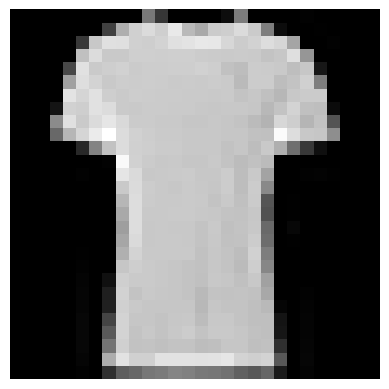

In [25]:
plt.imshow(images[5999], cmap="gray")
plt.axis("off")
plt.show()